In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from copy import copy
import pickle

%matplotlib widget

In [2]:
with open('LT402chip6_master.pkl', 'rb') as f:
    master = pickle.load(f)
f0s = master['trimmeasured 2']['f0']

In [3]:
f1, s1 = np.load('VNAsweep_25mK.npy')
f2, s2 = np.load('VNAsweep_25mK_20260203.npy')
f3, s3 = np.load('VNAsweep_25mK_20260203_2ndcooldown.npy')
s1 -= np.amax(s1)
s2 -= np.amax(s2)
s3 -= np.amax(s3)

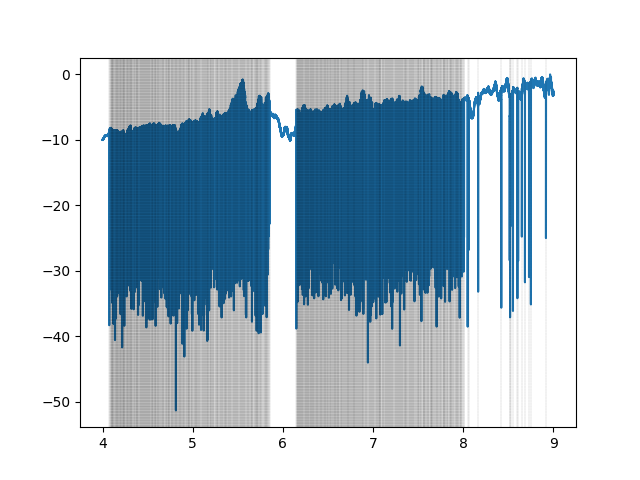

In [4]:
fig, ax = plt.subplots()
ax.plot(f3, s3, label='2nd cooldown')

for f0 in f0s:
    ax.axvline(f0, color='k', ls='--', lw=.1)

In [31]:
def track_tones(f0s, f, s, limit=5):
    new_f0s = []
    for f0 in f0s:
        if np.isnan(f0):
            new_f0s.append(np.nan)
        else:
            loc = int(np.argmin(np.abs(f - f0)))
            shift = np.argmin(s[loc:loc+limit])
            new_loc = loc+shift
            new_f0s.append(f[new_loc])
    return np.array(new_f0s)

f0s3 = track_tones(f0s, f3, s3, 10)
print(len(f0s3))

1024


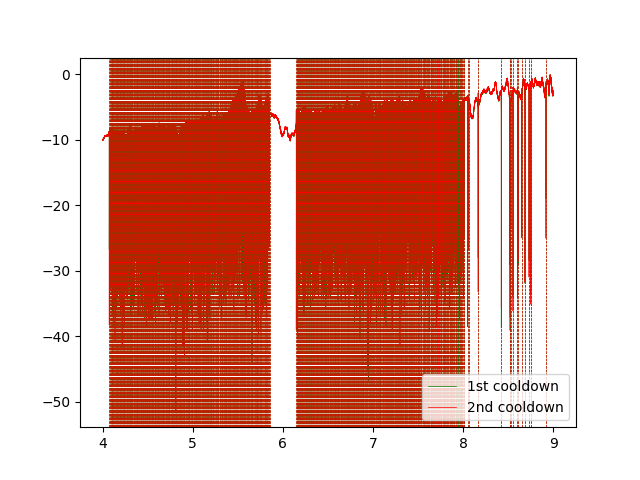

In [32]:
fig, ax = plt.subplots()
# ax.plot(f1, s1, lw=.5)
ax.plot(f2, s2, lw=.5, c='g', label='1st cooldown')
ax.plot(f3, s3, lw=.5, c='r', label='2nd cooldown')

for i, f0 in enumerate(f0s):
    ax.axvline(f0, color='g', ls='--', lw=.5)
    ax.axvline(f0s3[i], color='r', ls='--', lw=.5)
ax.legend()


In [33]:
master['trimdesign 3'] = {}
master['trimdesign 3']['f0'] = master['trimmeasured 2']['f0']
master['trimmeasured 3'] = {}
master['trimmeasured 3']['f0'] = f0s3


In [34]:
with open('LT402chip6_master.pkl', 'wb') as f:
    pickle.dump(master, f)

1.815631120627221e-06

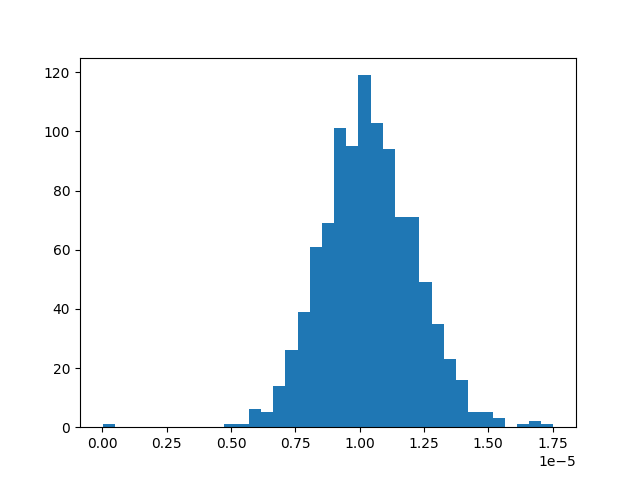

In [9]:
design = master['trimdesign 3']['f0']
meas = master['trimmeasured 3']['f0']
fig, ax = plt.subplots()
df_f = (meas-design)/design
ax.hist(df_f, bins='auto')
np.nanstd(df_f)